#  Simulating an observation of a SNR with CTAO
---

**Objective:** Use the spectral model fitted for the Crab data, obtained using the package NAIMA, to simulate how CTAO would observed an extended SNR, applying the spatial template for RXJ1713

**Workflow:**

```
 Crab data →  NAIMA fit (Synchrotron + IC)  →  SED modelled
       ↓
RXJ1713 spatial template
       ↓
SkyModel Gammapy  →  Simulating an observation with CTA  →  3D counts map
       ↓
Excess map + Significance map
```


---
## Part 1 — Crab model with `naima`


In [ ]:
# ============================================================
# CÉLULA 1 — Installing packages
# ============================================================
!pip install naima gammapy
!gammapy download datasets --out $HOME/gammapy-datasets

import os
os.environ["GAMMAPY_DATA"] = os.path.expanduser("~/gammapy-datasets/2.1")
print(f"GAMMAPY_DATA = {os.environ['GAMMAPY_DATA']}")


INFO:gammapy.scripts.download:Downloading datasets from https://github.com/gammapy/gammapy-data/tarball/v2.1
279MB [00:12, 23.5MB/s]
INFO:gammapy.scripts.download:Extracting /root/gammapy-datasets/2.1/datasets.tar.gz

*** You might want to declare GAMMAPY_DATA as a global env variable
export GAMMAPY_DATA=$PWD//root/gammapy-datasets/2.1

Or as part of your conda environment:
conda env config vars set GAMMAPY_DATA=$PWD//root/gammapy-datasets/2.1
conda activate gammapy-2.1

GAMMAPY_DATA = /root/gammapy-datasets/2.1


In [ ]:
# ============================================================
# CÉLULA 2 — Importing packages
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import astropy.units as u
from astropy.constants import c
from astropy.coordinates import SkyCoord
from astropy.io import ascii
import matplotlib.pyplot as plt
import naima
from naima.models import ExponentialCutoffBrokenPowerLaw, InverseCompton, Synchrotron



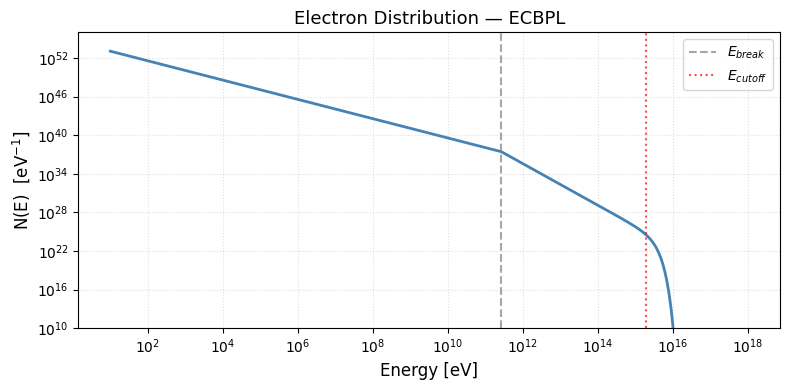

In [ ]:
# ============================================================
# CÉLULA 3 — Particle Distribution (ECBPL)
# ============================================================
# Fitted parameters for the multiwavelength Crab data
ECBPL = ExponentialCutoffBrokenPowerLaw(
    amplitude = 3.699e36 / u.eV,
    e_0       = 1      * u.TeV,
    e_break   = 0.265  * u.TeV,
    alpha_1   = 1.5,
    alpha_2   = 3.233,
    e_cutoff  = 1863   * u.TeV,
    beta      = 2.0,
)

# ── Visualizing the distribution ──────────────────────────
E_part = np.logspace(1, 18, 300) * u.eV

def ecbpl_eval(E):
    amp, e0, eb = 3.699e36/u.eV, 1*u.TeV, 0.265*u.TeV
    a1, a2, ec, beta = 1.5, 3.233, 1863*u.TeV, 2.0
    cut = np.exp(-(E/ec)**beta)
    if E < eb:
        return cut * amp * (E/e0)**(-a1)
    return cut * amp * (eb/e0)**(a2-a1) * (E/e0)**(-a2)

N_part = np.array([ecbpl_eval(E).to(1/u.eV).value for E in E_part])

fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(E_part.to(u.eV).value, N_part, lw=2, color="steelblue")
ax.set_xlabel("Energy [eV]", fontsize=12)
ax.set_ylabel(r"N(E)  [eV$^{-1}$]", fontsize=12)
ax.set_title("Electron Distribution — ECBPL", fontsize=13)
ax.axvline((0.265*u.TeV).to(u.eV).value, ls="--", color="gray", alpha=0.7, label=r"$E_{break}$")
ax.axvline((1863 *u.TeV).to(u.eV).value, ls=":",  color="red",  alpha=0.7, label=r"$E_{cutoff}$")
ax.legend()
ax.grid(True, which="both", ls=":", alpha=0.4)
ax.set_ylim(1e10, 1e56)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# CÉLULA 4 — Radiative Models (Synchrotron + IC)
# ============================================================

# ── Synchrotron ──────────────────────────────────────────
B    = 125 * u.uG
Rpwn = 2.1  * u.pc

SYN = Synchrotron(ECBPL, B=B, Eemax=50*u.PeV, Eemin=0.1*u.GeV)

E_sy  = np.logspace(-7, 9, 100) * u.eV
L_sy  = SYN.flux(E_sy, distance=0 * u.cm)
phn_sy = L_sy / (4 * np.pi * Rpwn**2 * c) * 2.24

# ── Inverse Compton ──────────────────────────────────────
IC = InverseCompton(
    ECBPL,
    seed_photon_fields=[
        "CMB",
        ["FIR", 70   * u.K,   0.5 * u.eV / u.cm**3],
        ["NIR", 5000 * u.K,   1.0 * u.eV / u.cm**3],
        ["SSC", E_sy, phn_sy],
    ],
    Eemax=50*u.PeV,
    Eemin=0.1*u.GeV,
)


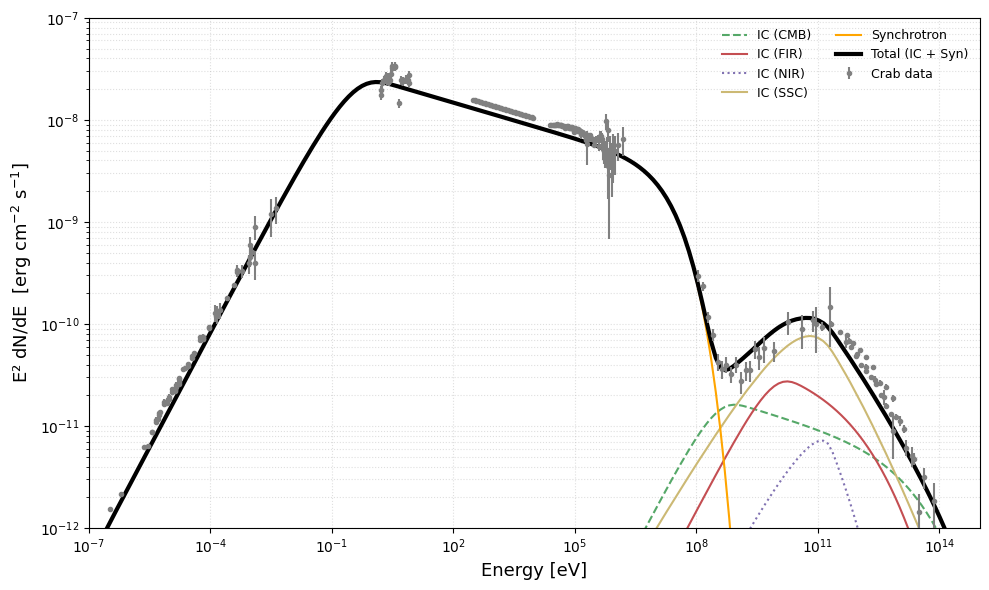

In [ ]:
# ============================================================
# CÉLULA 5 — SED modelled vs Crab data
# ============================================================
d      = 2.2 * u.kpc
energy = np.logspace(-7, 15, 200) * u.eV

fig, ax = plt.subplots(figsize=(10, 6))

# Individual Components
colors_ic = [naima.plot.color_cycle[i+1] for i in range(4)]
for seed, ls, color in zip(["CMB","FIR","NIR","SSC"],
                            ["--","-",":","-"],
                            colors_ic):
    ax.loglog(energy, IC.sed(energy, d, seed=seed),
              lw=1.5, ls=ls, color=color, label=f"IC ({seed})")

ax.loglog(energy, SYN.sed(energy, d), lw=1.5, ls="-", color="orange", label="Synchrotron")
ax.loglog(energy, IC.sed(energy, d) + SYN.sed(energy, d),
          lw=3, color="k", label="Total (IC + Syn)")

# Data
try:
    data = ascii.read("CrabNebula_spectrum.ecsv")
    ax.errorbar(
        data["energy"].to(u.eV).value,
        data["flux"].to(u.erg * u.cm**-2 * u.s**-1).value,
        yerr=data["flux_error"].to(u.erg * u.cm**-2 * u.s**-1).value,
        fmt=".", ls="none", color="grey", zorder=5, label="Crab data"
    )
except Exception:
    ax.text(0.05, 0.05, "data file not found", transform=ax.transAxes,
            color="red", fontsize=10)

ax.set_xlim(1e-7, 1e15)
ax.set_ylim(1e-12, 1e-7)
ax.set_xlabel("Energy [eV]", fontsize=13)
ax.set_ylabel(r"E² dN/dE  [erg cm$^{-2}$ s$^{-1}$]", fontsize=13)
#ax.set_title("SED", fontsize=14)
ax.legend(fontsize=9, frameon=False, ncol=2)
ax.grid(True, which="both", ls=":", alpha=0.4)
plt.tight_layout()
plt.show()


---
## Parte 2 — Simulating an observation with `gammapy`


Now we use the modelled spectra applying the spatial template from RXJ1713


In [ ]:
# ============================================================
# CÉLULA 6 — Importações do Gammapy
# ============================================================
from gammapy.data import FixedPointingInfo, Observation, observatory_locations
from gammapy.datasets import MapDataset
from gammapy.irf import load_irf_dict_from_file
from gammapy.makers import MapDatasetMaker, SafeMaskMaker, FoVBackgroundMaker
from gammapy.maps import MapAxis, WcsGeom, Map
from gammapy.modeling.models import (
    FoVBackgroundModel,
    Models,
    SkyModel,
    TemplateSpatialModel,
    TemplateSpectralModel,
    PowerLawNormSpectralModel,
)
from gammapy.estimators import ExcessMapEstimator
from regions import CircleSkyRegion
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt




Energy min/max : 0.10 TeV / 100.00 TeV
Unity naima   : 1 / (eV s cm2)
Unity Gammapy : 1 / (TeV s cm2)
Flux @ 1 TeV   : 2.130e-11 1 / (TeV s cm2)
Max Flux    : 6.818e-09 1 / (TeV s cm2)
Min Flux    : 8.088e-17 1 / (TeV s cm2)


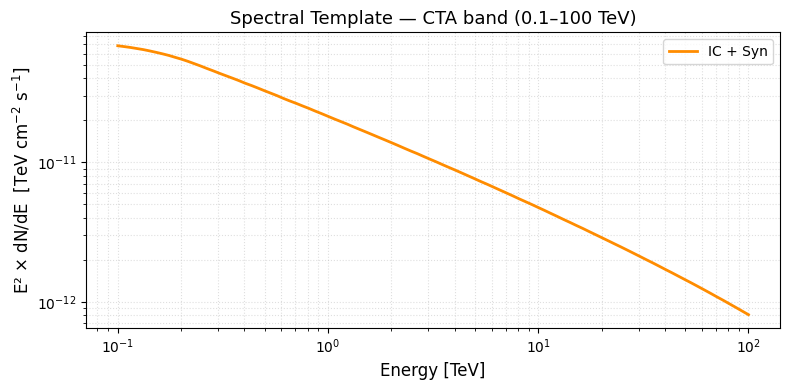

In [ ]:
# ============================================================
# CÉLULA 7 — Converting the naima spectrum
# ============================================================
# O CTA South covers the 0.1 – 100 TeV band

E_TeV = np.logspace(-1, 2, 100) * u.TeV
E_eV  = E_TeV.to(u.eV)

# Fluxo total (IC + Syn) in cm⁻² s⁻¹ eV⁻¹
flux_naima = IC.flux(E_eV, d) + SYN.flux(E_eV, d)

flux_TeV  = flux_naima.to(1 / (u.TeV * u.cm**2 * u.s))
values_sim = flux_TeV.value / u.TeV / u.cm**2 / u.s

# Sanity
print(f"Energy min/max : {E_TeV.min():.2f} / {E_TeV.max():.2f}")
print(f"Unity naima   : {flux_naima.unit}")
print(f"Unity Gammapy : {flux_TeV.unit}")
idx_1TeV = np.argmin(np.abs(E_TeV.value - 1.0))
print(f"Flux @ 1 TeV   : {flux_TeV[idx_1TeV]:.3e}")
print(f"Max Flux    : {flux_TeV.max():.3e}")
print(f"Min Flux    : {flux_TeV.min():.3e}")

# Visualizing the spectral template
fig, ax = plt.subplots(figsize=(8, 4))
ax.loglog(E_TeV.value, E_TeV.value**2 * flux_TeV.value,
          lw=2, color="darkorange", label="IC + Syn")
ax.set_xlabel("Energy [TeV]", fontsize=12)
ax.set_ylabel(r"E² × dN/dE  [TeV cm$^{-2}$ s$^{-1}$]", fontsize=12)
ax.set_title("Spectral Template — CTA band (0.1–100 TeV)", fontsize=13)
ax.grid(True, which="both", ls=":", alpha=0.4)
ax.legend()
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# CÉLULA 8 — Template Espacial (RXJ1713) + SkyModel
# ============================================================
import os

# ── Template espacial ─────────────────────────────────────
filename = os.path.join(
    os.environ["GAMMAPY_DATA"],
    "catalogs/fermi/Extended_archive_v18/Templates/RXJ1713_2016_250GeV.fits"
)

m = Map.read(filename)
m = m.copy(unit="sr^-1")
spatial_model = TemplateSpatialModel(m, filename=filename)


# ── Template espectral ────
template_espectral = TemplateSpectralModel(
    energy = E_TeV,
    values = values_sim,
)

# ── SkyModel combinado ────────────────────────────────────
model_simu = SkyModel(
    spatial_model  = spatial_model,
    spectral_model = template_espectral,
    name           = "SNR-template",
)

print(model_simu)


SkyModel

  Name                      : SNR-template
  Datasets names            : None
  Spectral model type       : TemplateSpectralModel
  Spatial  model type       : TemplateSpatialModel
  Temporal model type       : 
  Parameters:
    lon_0                 (frozen):    258.388       deg         
    lat_0                 (frozen):    -39.762       deg         




In [ ]:
# ============================================================
# CÉLULA 9 — Geometria da Observação e IRFs
# ============================================================

# ── IRFs do CTA Sul ───────────────────────────────────────
irfs = load_irf_dict_from_file(
    os.path.join(os.environ["GAMMAPY_DATA"],
                 "cta-1dc/caldb/data/cta/1dc/bcf/South_z20_50h/irf_file.fits")
)

# ── Pointing: centro do template do RXJ1713 ───────────────
pointing_pos  = spatial_model.map.geom.center_skydir
pointing_icrs = FixedPointingInfo(fixed_icrs=pointing_pos.icrs)
livetime      = 2.0 * u.hr

print(f"Pointing : {pointing_pos}")
print(f"Livetime : {livetime}")

# ── Emergy Axes ──────────────────────────────────────
energy_reco = MapAxis.from_edges(
    np.logspace(-1.0, 1.0, 11), unit="TeV", name="energy", interp="log"
)
energy_true = MapAxis.from_edges(
    np.logspace(-1.5, 1.5, 30), unit="TeV", name="energy_true", interp="log"
)

# ── WCS geometry centered on the template ────────────────────
geom = WcsGeom.create(
    skydir = pointing_pos,
    binsz  = 0.02,
    width  = (6, 6),
    frame  = m.geom.frame,
    axes   = [energy_reco],
)

empty_dataset = MapDataset.create(
    geom, name="dataset-simu", energy_axis_true=energy_true
)


print(geom)


Pointing : <SkyCoord (FK5: equinox=2000.0): (ra, dec) in deg
    (258.388, -39.7621994)>
Livetime : 2.0 h
WcsGeom

	axes       : ['lon', 'lat', 'energy']
	shape      : (np.int64(300), np.int64(300), 10)
	ndim       : 3
	frame      : fk5
	projection : CAR
	center     : 258.4 deg, -39.8 deg
	width      : 6.0 deg x 6.0 deg
	wcs ref    : 258.4 deg, -39.8 deg



In [ ]:
# ============================================================
# CÉLULA 10 — Simulação the Observation (fake dataset)
# ============================================================

# ── Observation ────────────────────────────────────────────
location = observatory_locations["ctao_south"]
obs = Observation.create(
    pointing = pointing_icrs,
    livetime = livetime,
    irfs     = irfs,
    location = location,
)

# ── Building the MapDataset ──────────────────────────────
maker           = MapDatasetMaker(selection=["exposure","background","psf","edisp"])
maker_safe_mask = SafeMaskMaker(methods=["offset-max"], offset_max=4.0 * u.deg)

dataset = maker.run(empty_dataset, obs)
dataset = maker_safe_mask.run(dataset, obs)

# ── Add the model and generate the counts ───────
dataset.models = Models([model_simu, FoVBackgroundModel(dataset_name="dataset-simu")])
dataset.fake()

print("Simulated dataset:")
print(dataset)



Simulated dataset:
MapDataset
----------

  Name                            : dataset-simu 

  Total counts                    : 171723 
  Total background counts         : 161854.76
  Total excess counts             : 9868.24

  Predicted counts                : 171869.34
  Predicted background counts     : 161854.76
  Predicted excess counts         : 10014.59

  Exposure min                    : 4.08e+02 m2 s
  Exposure max                    : 3.58e+10 m2 s

  Number of total bins            : 900000 
  Number of fit bins              : 893880 

  Fit statistic type              : cash
  Fit statistic value (-2 log(L)) : 604085.21

  Number of models                : 2 
  Number of parameters            : 5
  Number of free parameters       : 1

  Component 0: SkyModel
  
    Name                      : SNR-template
    Datasets names            : None
    Spectral model type       : TemplateSpectralModel
    Spatial  model type       : TemplateSpatialModel
    Temporal model type 

---
## Parte 3 — Counts, Excess and Significance Maps

With the dataset we can visualize:

1. **Counts Map** — what CTA would "see" (signal + background)
2. **Excess Map** — source counts after removing the background
3. **Significance Map** — statistical detection in each pixel


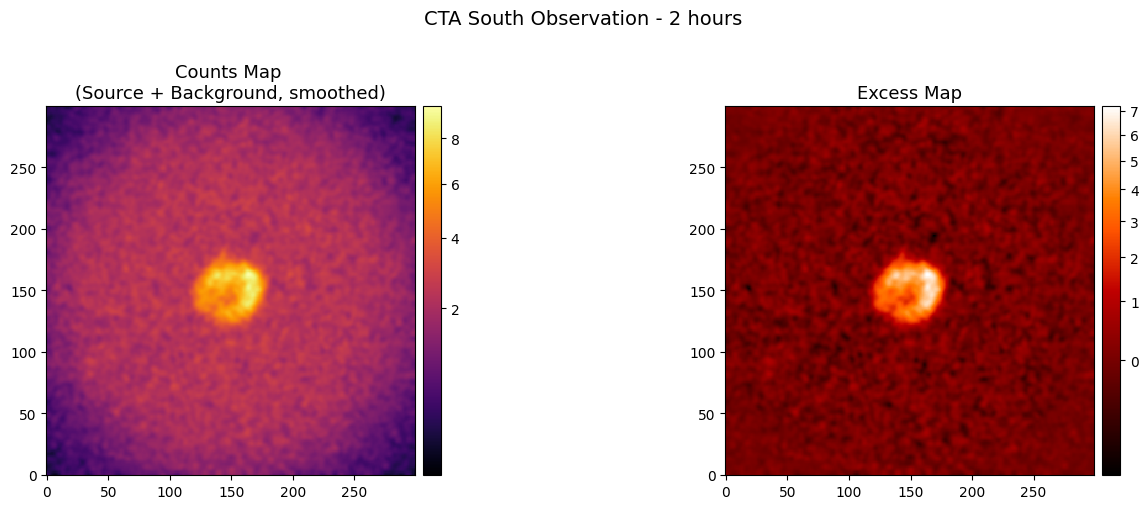

In [ ]:
# ============================================================
# CÉLULA 11 — 3D Counts Map (integrate in energy)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total Counts Map
counts_2d = dataset.counts.sum_over_axes().smooth(0.04 * u.deg)
counts_2d.plot(ax=axes[0], cmap="inferno", add_cbar=True, stretch="sqrt")
axes[0].set_title("Counts Map \n(Source + Background, smoothed)", fontsize=13)

# Excess Map
excess_2d = dataset.excess.sum_over_axes().smooth(0.04 * u.deg)
excess_2d.plot(ax=axes[1], cmap="gist_heat", add_cbar=True, stretch="sqrt")
axes[1].set_title("Excess Map", fontsize=13)

plt.suptitle("CTA South Observation - 2 hours", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


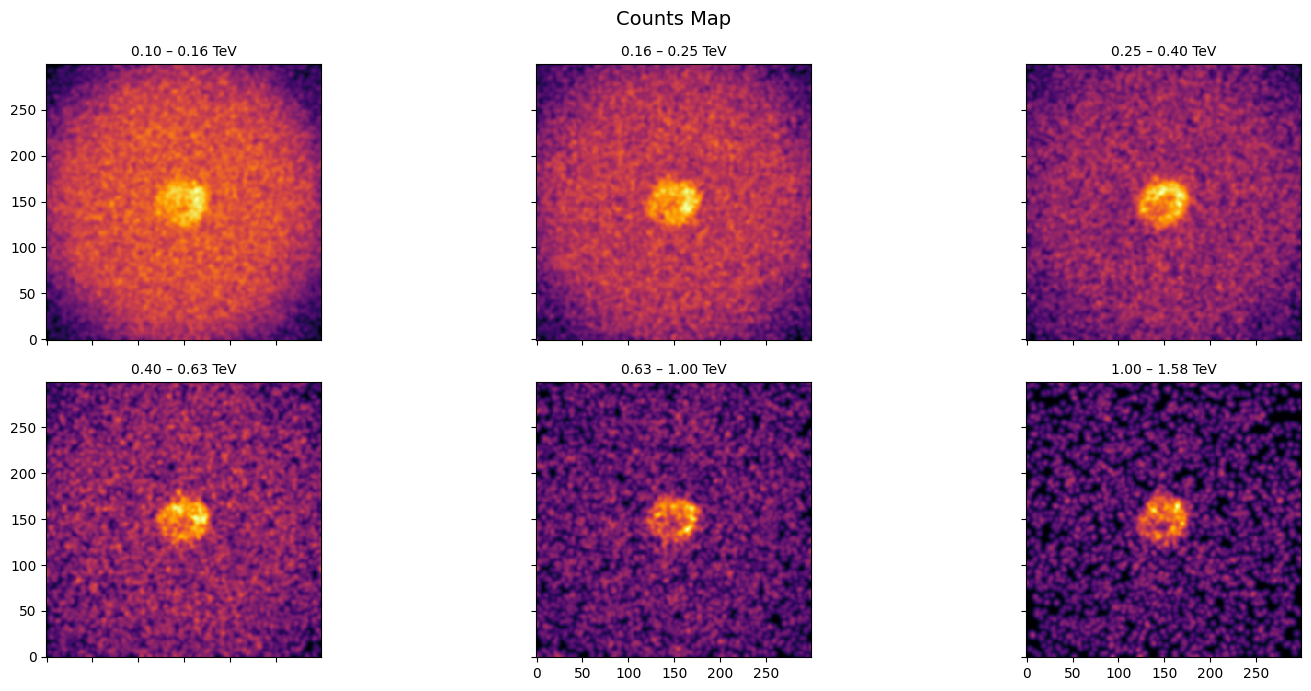

In [ ]:
# ============================================================
# CÉLULA 12 — Counts Map for eacg=h energy
# ============================================================

n_bins = dataset.counts.data.shape[0]
n_show = min(6, n_bins)
edges  = energy_reco.edges.to(u.TeV)

fig, axes = plt.subplots(2, n_show // 2, figsize=(16, 7))
axes = axes.flatten()

for i in range(n_show):
    ax = axes[i]

    counts_slice = dataset.counts.slice_by_idx({"energy": i})
    counts_slice.smooth(0.04 * u.deg).plot(
        ax=ax, cmap="inferno", add_cbar=False, stretch="sqrt"
    )
    e_lo = edges[i].value
    e_hi = edges[i+1].value
    ax.set_title(f"{e_lo:.2f} – {e_hi:.2f} TeV", fontsize=10)
    ax.tick_params(labelbottom=(i >= n_show - 2))
    ax.tick_params(labelleft=(i % (n_show // 2) == 0))

plt.suptitle("Counts Map", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# CÉLULA 13 — Background Refitting + Excess Estimator
# ============================================================
# To correctly determine the significance we exclude the source region

# Exclusion mask around the template center
source_pos = spatial_model.map.geom.center_skydir

excl_region = CircleSkyRegion(center=source_pos, radius=1.5 * u.deg)
geom_excl   = WcsGeom.create(skydir=source_pos, binsz=0.02, width=(6,6),
                              frame=m.geom.frame)
exclusion_mask = ~geom_excl.region_mask([excl_region])

# Refitting the Background (FoVBackgroundMaker)
bkg_spectral = PowerLawNormSpectralModel()
maker_fov    = FoVBackgroundMaker(method="fit",
                                   exclusion_mask=exclusion_mask,
                                   spectral_model=bkg_spectral)

dataset_det = dataset.copy(name="dataset-det")
dataset_det.models = Models([FoVBackgroundModel(dataset_name="dataset-det")])
dataset_det = maker_fov.run(dataset_det)

print(f"Refitted norm : "
      f"{dataset_det.background_model.spectral_model.norm.value:.4f}")

# ExcessMapEstimator
estimator = ExcessMapEstimator(
    correlation_radius = 0.1 * u.deg,
    selection_optional = "all",
)
result = estimator.run(dataset_det)

significance_map = result["sqrt_ts"]
excess_map       = result["npred_excess"]
print("\n✓ Excess map and Calculated Significance")


Refitted norm : 1.0027

✓ Excess map and Calculated Significance


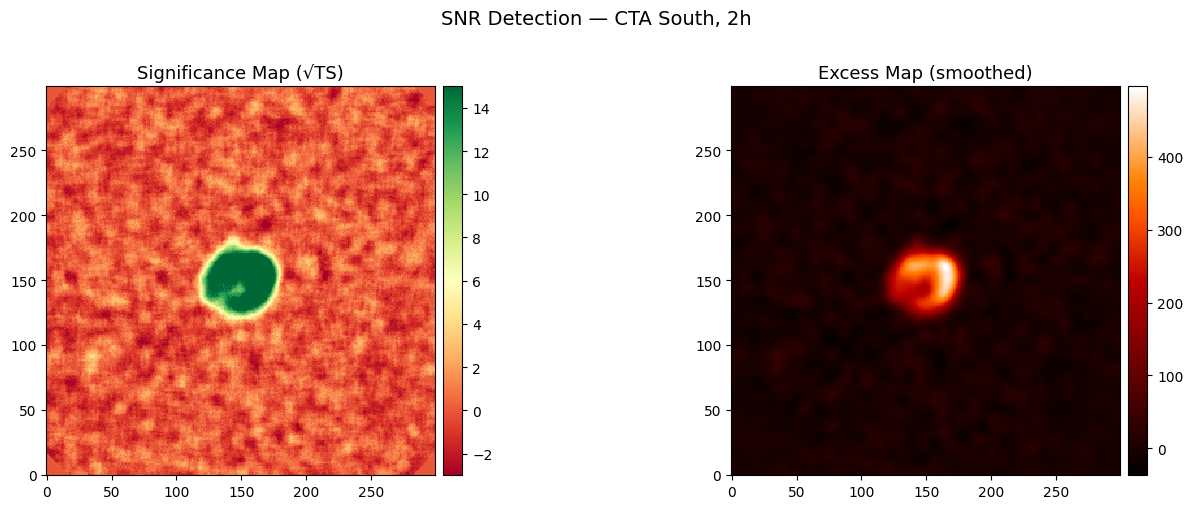

In [ ]:
# ============================================================
# CÉLULA 14 — Significance and Excess Map
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

significance_map.sum_over_axes().plot(
    ax=axes[0], add_cbar=True, cmap="RdYlGn", vmin=-3, vmax=15
)
axes[0].set_title("Significance Map (√TS)", fontsize=13)

excess_map.sum_over_axes().smooth("0.05 deg").plot(
    ax=axes[1], add_cbar=True, cmap="gist_heat"
)
axes[1].set_title("Excess Map (smoothed)", fontsize=13)

plt.suptitle("SNR Detection — CTA South, 2h", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
# ============================================================
# CÉLULA 15 — Detection Statistics
# ============================================================
import numpy as np

sig_data    = significance_map.sum_over_axes().data
finite_mask = np.isfinite(sig_data)
sig_finite  = sig_data[finite_mask]

print("=" * 45)
print("   Simulated Detection Summary")
print("=" * 45)
print(f"  Livetime               : {livetime}")
print(f"  Total Counts      : {int(dataset.counts.data.sum())}")
print(f"  Background Counts     : {int(dataset.background.data.sum())}")
print(f"  Total Excess          : {int(dataset.counts.data.sum() - dataset.background.data.sum())}")
print(f"  Maximum Significance  : {np.nanmax(sig_finite):.1f} σ")
print(f"  Median Significance  : {np.nanmedian(sig_finite):.2f} σ")
print(f"  Pixels with sig > 5σ    : {np.sum(sig_finite > 5)}")
print(f"  Pixels with sig > 3σ    : {np.sum(sig_finite > 3)}")
print("=" * 45)


   Simulated Detection Summary
  Livetime               : 2.0 h
  Total Counts      : 171885
  Background Counts     : 162027
  Total Excess          : 9857
  Maximum Significance  : 30.2 σ
  Median Significance  : 0.02 σ
  Pixels with sig > 5σ    : 2780
  Pixels with sig > 3σ    : 3217


What else can be done?



*   Vary livetime to see how the observation in impacted.
*   Change the spatial template for a gaussian model
*   Vary the source distance to analyze how the observation changes in morphology and in significance. For example, at which distance the source becomes undetectable?

